
# Decision Tree Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Step 1: Load Real-World Dataset

We are using the California Housing Dataset.
Target variable:
- House Price


In [ ]:
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

X.head()

Feature Shape: (20640, 8)
Target Shape: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



# Step 2: Explore Dataset


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [ ]:
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000



# Step 3: Train-Test Split


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)



# Step 4: Build Decision Tree Regression Model


In [ ]:

model = DecisionTreeRegressor(random_state=42)

model.fit(X_train, y_train)

print("Model Training Completed")


Model Training Completed



# Step 5: Make Predictions


In [ ]:

y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])


First 10 Predictions:
[0.414   1.203   5.00001 2.17    2.257   1.787   2.217   1.74    2.772
 5.00001]



# Step 6: Evaluate Model Performance


In [ ]:

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", mse**0.5)
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)


Mean Squared Error: 0.495235205629094
Root Mean Squared Error: 0.7037294974840077
Mean Absolute Error: 0.45467918846899225
R2 Score: 0.622075845135081



# Step 7: Actual vs Predicted Visualization


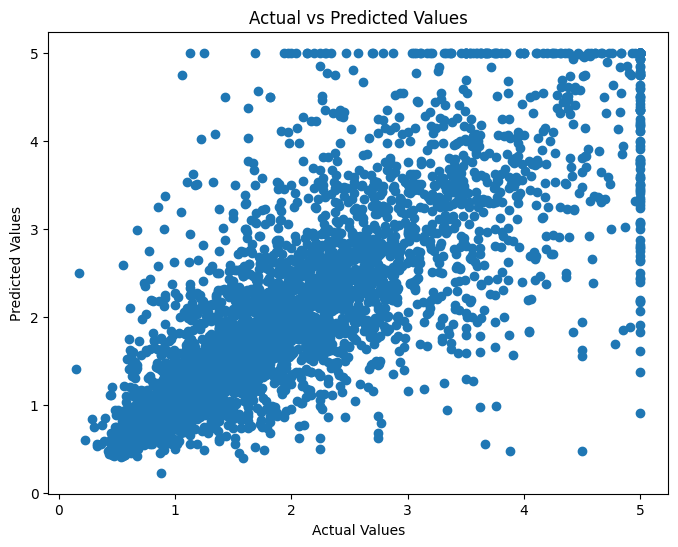

In [ ]:

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

plt.show()



# Step 8: Visualize Decision Tree

Smaller tree used for better understanding.


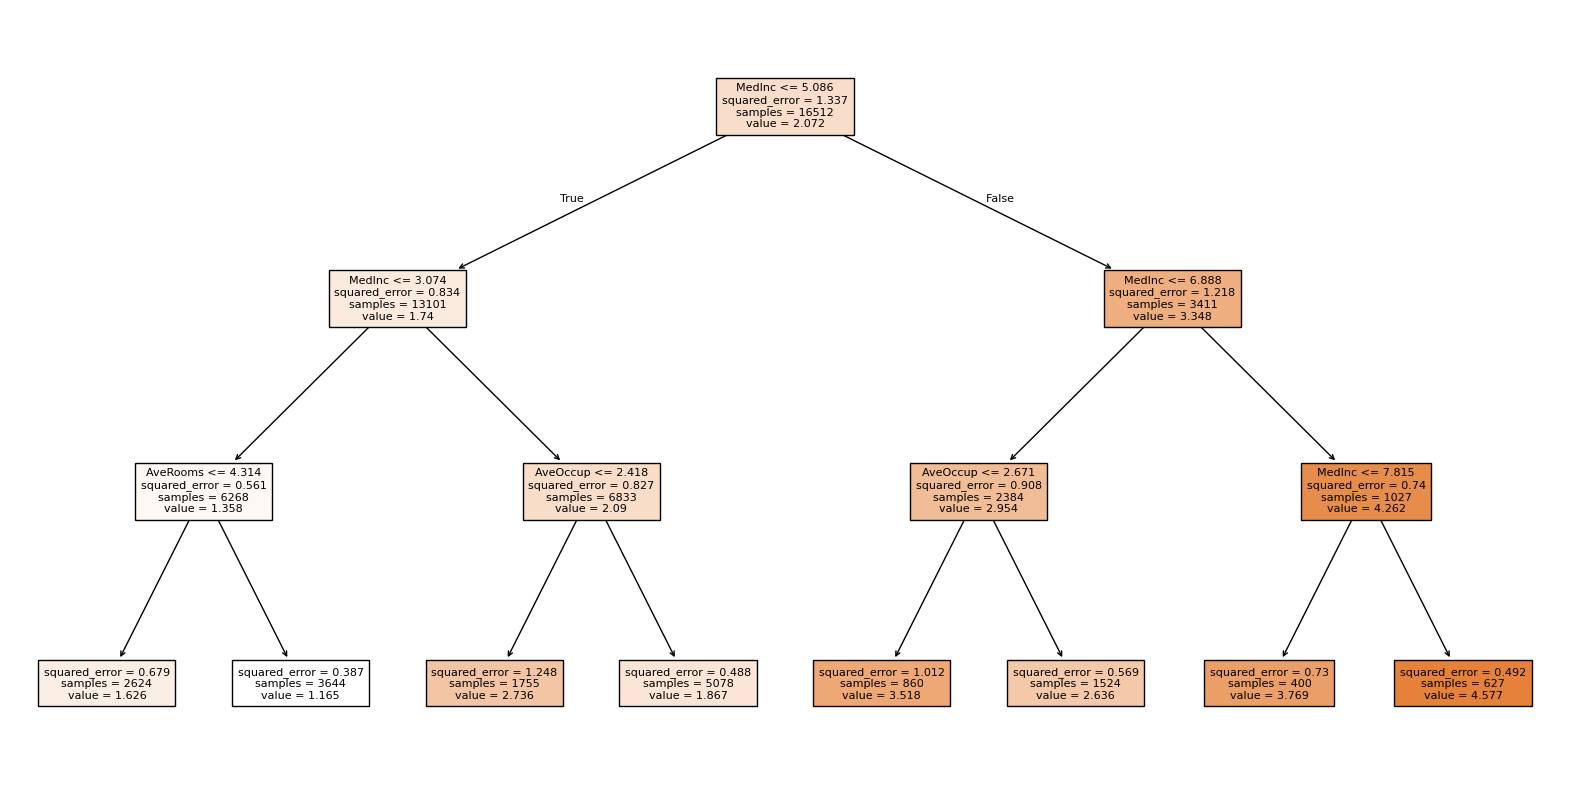

In [ ]:

small_tree = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

small_tree.fit(X_train, y_train)

plt.figure(figsize=(20,10))

plot_tree(
    small_tree,
    feature_names=X.columns,
    filled=True,
    fontsize=8
)

plt.show()



# Step 9: Overfitting vs Underfitting

Decision Trees can overfit very easily.

We analyze the effect of tree depth.


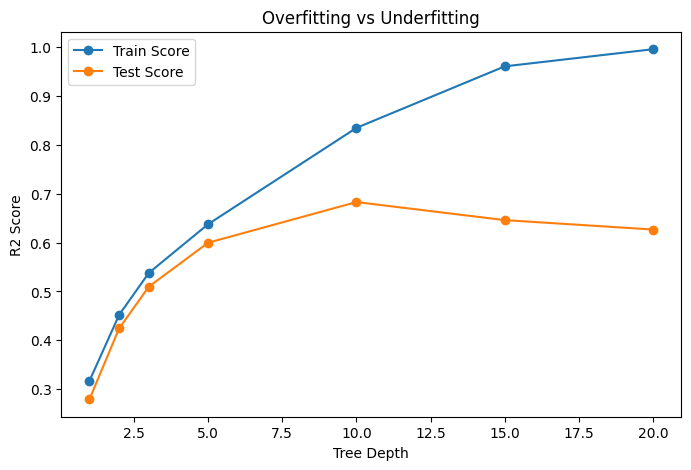

In [ ]:

depths = [1, 2, 3, 5, 10, 15, 20]

train_scores = []
test_scores = []

for depth in depths:

    temp_model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    temp_model.fit(X_train, y_train)

    train_scores.append(temp_model.score(X_train, y_train))
    test_scores.append(temp_model.score(X_test, y_test))

plt.figure(figsize=(8,5))

plt.plot(depths, train_scores, marker='o', label='Train Score')
plt.plot(depths, test_scores, marker='o', label='Test Score')

plt.xlabel("Tree Depth")
plt.ylabel("R2 Score")
plt.title("Overfitting vs Underfitting")

plt.legend()

plt.show()



# Step 10: Feature Importance


In [ ]:

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df


,Feature,Importance
0,MedInc,0.528509
5,AveOccup,0.130838
6,Latitude,0.093717
7,Longitude,0.082902
2,AveRooms,0.052975
1,HouseAge,0.051884
4,Population,0.030516
3,AveBedrms,0.028660


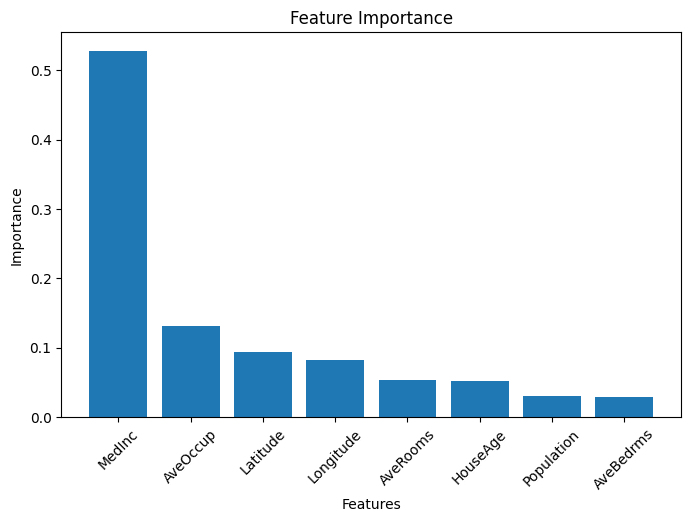

In [ ]:

plt.figure(figsize=(8,5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=45)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.show()



# Final Conclusion

Decision Tree Regression:
- Handles non-linear relationships
- Does not require feature scaling
- Easy to interpret
- Can easily overfit

Important Hyperparameters:
- max_depth
- min_samples_split
- min_samples_leaf


## For more reference:
1. https://youtu.be/RANHxyAvtM4
2. https://youtu.be/uHq0I_MDVZU
